# Análisis de Hotspots: Burger Master Bogotá 2022
## Identificación de zonas de concentración gastronómica con GMM y KDE

El Burger Master 2022 reunió a **63 restaurantes en 116 sedes** distribuidas por Bogotá. Este proyecto aplica análisis geoespacial para responder una pregunta concreta: **¿dónde se concentra la oferta y existen zonas claramente diferenciadas?**

Se comparan dos enfoques complementarios:

- **GMM (Modelo de Mezclas Gaussianas):** segmenta el mapa en zonas diferenciadas y asigna cada restaurante a un grupo geográfico.
- **KDE (Estimación de Densidad por Kernel):** genera una superficie continua que cuantifica la intensidad de la oferta por sector.

**Dataset:** 137 registros · 63 restaurantes · 116 sedes · Bogotá D.C. y Chía.

## 1. Dataset

El dataset contiene la información georreferenciada de las sedes participantes en el Burger Master 2022 en Bogotá. A continuación se carga y explora su estructura.

In [1]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 3.4 MB/s eta 0:00:00


In [12]:
# Librerias a utilizar
import scipy.stats
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import os
import re
import html
import unicodedata
import requests
import seaborn as sns
import geopandas as gpd
import statsmodels.api as sm
import folium
from folium.plugins import HeatMap
from branca.colormap import linear
from geopy.distance import geodesic
from shapely.geometry import Point
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from sklearn.mixture import GaussianMixture
import osmnx as ox
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Cargue de la información
data = pd.read_excel("data/burger_master.xlsx")

# Explorar la estructura de los datos
print("Forma de los datos:", data.shape)

print("\nInformación general:")
data.info()

print("\nPrimeras filas:")
display(data.head())

print("\nValores unicos por columna:")
for col in data.columns:
    print(f"'{col}':")
    if data[col].nunique() > 10:
        print(f"  Más de 10 valores únicos. Mostrando los primeros 10:")
        print(data[col].unique()[:10])
    else:
        print(data[col].unique())

print("\nCantidad restaurantes", data['Restaurante'].nunique())
print("Cantidad direcciones", data['Dirección'].nunique())
print("Cantidad descripciones", data['Descripción'].nunique())

Forma de los datos: (137, 5)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Restaurante  137 non-null    object 
 1   Dirección    137 non-null    object 
 2   Descripción  137 non-null    object 
 3   Latitud      137 non-null    float64
 4   Longitud     137 non-null    float64
dtypes: float64(2), object(3)
memory usage: 5.5+ KB

Primeras filas:


,Restaurante,Dirección,Descripción,Latitud,Longitud
0,MAIKKI,Cra 75 # 24D – 48,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.668833,-74.116828
1,MAIKKI,Calle 119 # 11A – 24,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.698395,-74.036585
2,MAIKKI,Cra 47A # 98 – 47,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.686401,-74.060144
3,FRENCHEESE,Calle 51 #22-55,"<p>Presentamos «La French Master», inspirada e...",4.639514,-74.073545
4,FRENCHEESE,Calle 80 #14-41,"<p>Presentamos «La French Master», inspirada e...",4.666147,-74.056758



Valores unicos por columna:
'Restaurante':
  Más de 10 valores únicos. Mostrando los primeros 10:
['MAIKKI' 'FRENCHEESE' 'BY BROTHERS BURGER' 'BOZGOS' 'GRATIN BURGER'
 'OVEJA NEGRA' 'THE CORNER BURGER' 'RUSTICA D.C' 'BEER LOVERS'
 'JIMMY BURGER']
'Dirección':
  Más de 10 valores únicos. Mostrando los primeros 10:
['Cra 75 # 24D – 48' 'Calle 119 # 11A – 24' 'Cra 47A # 98 – 47'
 'Calle 51 #22-55' 'Calle 80 #14-41' 'Diagonal 47 #74B – 80 Normandía'
 'Diagonal 40A # 7 – 38' 'Autopista norte #146-48' 'Av. Cra 24 #39B-20'
 'Av. Calle 100#50-08']
'Descripción':
  Más de 10 valores únicos. Mostrando los primeros 10:
['<p>MAIKKI MACUIRA: Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana<br/><br/>Cra 75 # 24D – 48, Modelia<b

**Estructura del dataset:** 137 sedes · 63 restaurantes · 116 ubicaciones únicas.

Variables disponibles: `Restaurante`, `Dirección`, `Descripción` (HTML), `Latitud`, `Longitud`. Las coordenadas cubren Bogotá D.C. y el municipio de Chía.

## 2. Distribución geográfica

Las 137 sedes se distribuyen principalmente en el eje norte-sur de Bogotá, con un grupo separado en Chía. El mapa interactivo permite explorar cada sede: al hacer clic sobre un marcador se despliega el nombre del restaurante, su dirección y la descripción de la hamburguesa participante.

In [4]:
# Función de limpieza de descripciones
def limpiar_descripcion(s):
    t = str(s)
    # Decodificar entidades HTML y normalizar unicode
    t = html.unescape(t)
    t = unicodedata.normalize("NFKC", t)
    # Quitar etiquetas HTML simples
    t = re.sub(r"<[^>]+>", " ", t)
    # Reemplazar comillas tipográficas y símbolos
    t = t.replace("“", '"').replace("”", '"').replace("’", "'").replace("«", '"').replace("»", '"')
    # Quitar caracteres no imprimibles
    t = "".join(ch for ch in t if ch.isprintable())
    # Colapsar espacios
    t = re.sub(r"\s+", " ", t).strip()
    return t

# Añadir columna con descripción limpia
data["Descripcion_limpia"] = data['Descripción'].apply(limpiar_descripcion)
display(data)

,Restaurante,Dirección,Descripción,Latitud,Longitud,Descripcion_limpia
0,MAIKKI,Cra 75 # 24D – 48,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.668833,-74.116828,"MAIKKI MACUIRA: Cama de chicharrón soplado, to..."
1,MAIKKI,Calle 119 # 11A – 24,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.698395,-74.036585,"MAIKKI MACUIRA: Cama de chicharrón soplado, to..."
2,MAIKKI,Cra 47A # 98 – 47,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado,...",4.686401,-74.060144,"MAIKKI MACUIRA: Cama de chicharrón soplado, to..."
3,FRENCHEESE,Calle 51 #22-55,"<p>Presentamos «La French Master», inspirada e...",4.639514,-74.073545,"Presentamos ""La French Master"", inspirada en n..."
4,FRENCHEESE,Calle 80 #14-41,"<p>Presentamos «La French Master», inspirada e...",4.666147,-74.056758,"Presentamos ""La French Master"", inspirada en n..."
...,...,...,...,...,...,...
132,THE CORNER BURGER,AV Pradilla # 06 – 95,<p>La morrocoya! Hamburguesa de 135gr de la me...,4.862641,-74.054350,La morrocoya! Hamburguesa de 135gr de la mezcl...
133,OVEJA NEGRA,Diagonal 7 #7-10,<p>Mezclamos la receta clásica de la hamburgue...,4.594460,-74.077271,Mezclamos la receta clásica de la hamburguesa ...
134,ANDRÉS PARADERO,Carrera 5#9-25,"<p>Ingredientes: Queso Mozzarella, Sal parrill...",4.741712,-74.063524,"Ingredientes: Queso Mozzarella, Sal parrillera..."
135,THE FAMILY HOUSE BURGER,Calle 2 #1-11,<p>Con ustedes… «LA H.P.» Hey hey tranqui… (La...,4.585902,-74.074474,"Con ustedes... ""LA H.P."" Hey hey tranqui... (L..."


In [5]:
# Crear mapa
# Preparar datos válidos para mapa
df_mapa = data.dropna(subset=["Latitud", "Longitud"]).copy()

# Convertir a GeoDataFrame
gdf_mapa = gpd.GeoDataFrame(
    df_mapa,
    geometry=gpd.points_from_xy(df_mapa["Longitud"], df_mapa["Latitud"])
)

# Centrar mapa en Bogotá
centro_bogota = [4.7110, -74.0721]
mapa_areas = folium.Map(location=centro_bogota, zoom_start=12, tiles="OpenStreetMap")

# Añadir marcadores con popup y tooltip
for idx, row in gdf_mapa.iterrows():

    # Agregar popup con descripcion
    nombre = row.get("Restaurante", "Restaurante")
    direccion = row.get("Dirección", row.get("Direccion", ""))
    desc_limpia = row.get("Descripcion_limpia", "")
    popup_html = f"""
    <div style="width:300px;">
        <b>{nombre}</b><br/>
        <i>{direccion}</i><br/><br/>
        <div style="font-size: 11px; line-height:1.2;">{desc_limpia}</div>
    </div>
    """
    # Popup con folium
    folium.Marker(
        location=[row["Latitud"], row["Longitud"]],
        tooltip=nombre,
        popup=folium.Popup(popup_html, max_width=300),
        icon=folium.Icon(icon="info-sign")
    ).add_to(mapa_areas)

folium.LayerControl().add_to(mapa_areas)

# Mostrar el mapa
display(mapa_areas)

El campo `Descripción` contiene HTML con información adicional de direcciones. Se implementó una función de limpieza que decodifica entidades HTML, elimina etiquetas y normaliza el texto. El resultado se almacena en `Descripcion_limpia` para su uso en los popups del mapa.

## 3. Segmentación por zonas: GMM

El **Modelo de Mezclas Gaussianas (GMM)** representa la distribución espacial de los restaurantes como una suma de gaussianas, donde cada componente corresponde a una zona geográfica.

**Selección de hiperparámetros:** se evaluaron k = 1–12 componentes y cuatro estructuras de covarianza (`full`, `tied`, `diag`, `spherical`). El criterio de selección es el **BIC**, que penaliza la complejidad del modelo para evitar sobreajuste.

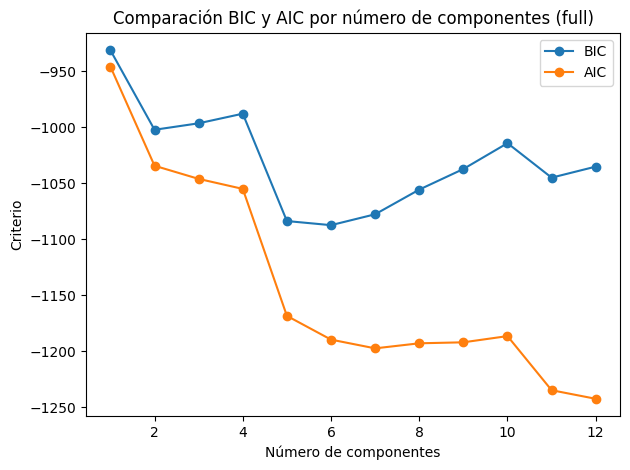

In [7]:
# Construir matriz de características X
df_geo = data.dropna(subset=["Latitud", "Longitud"]).copy()
X = df_geo[["Latitud", "Longitud"]].to_numpy()

# Barrido de hiperparámetros: número de componentes y estructura de covarianza
cov_types = ["full", "tied", "diag", "spherical"]
n_components_grid = list(range(1, 13))

results = []
for cov in cov_types:
    for k in n_components_grid:
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=1234)
        gmm.fit(X)
        aic = gmm.aic(X)
        bic = gmm.bic(X)
        results.append({"covariance_type": cov, "n_components": k, "AIC": aic, "BIC": bic})
res_df = pd.DataFrame(results)

# Selección del mejor modelo
idx_best = res_df["BIC"].idxmin()
best_row = res_df.loc[idx_best].to_dict()
best_cov = best_row["covariance_type"]
best_k = int(best_row["n_components"])

# Gráfica comparativa BIC y AIC
res_sel = res_df[res_df["covariance_type"] == best_cov].sort_values("n_components")
plt.figure()
plt.plot(res_sel["n_components"], res_sel["BIC"], marker="o", label="BIC")
plt.plot(res_sel["n_components"], res_sel["AIC"], marker="o", label="AIC")
plt.xlabel("Número de componentes")
plt.ylabel("Criterio")
plt.title(f"Comparación BIC y AIC por número de componentes ({best_cov})")
plt.legend()
plt.tight_layout()
plt.show()

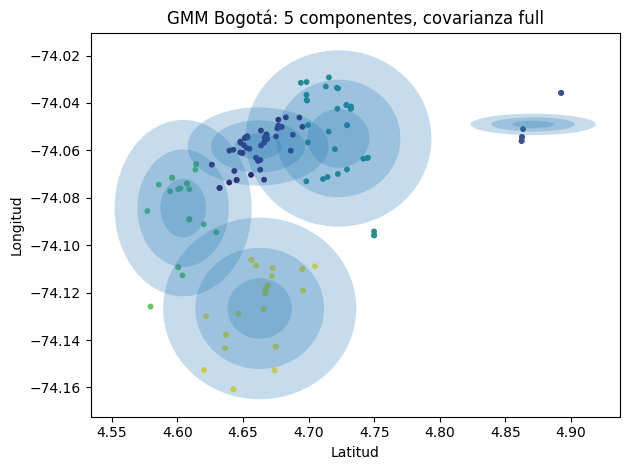

In [8]:
# Ajuste con los hiperparámetros seleccionados con base al procedimiento anterior
# Con base en la gráfica no hay mayor diferencia entre 5 o 6 componentes, se seleccionan 5 para mantener el modelo más simple
best_k = best_k - 1 # 5 componentes
best_gmm = GaussianMixture(n_components=best_k, covariance_type=best_cov, random_state=1234).fit(X)
labels = best_gmm.predict(X)

# Visualizar elipses de covarianza
# Funciones auxiliares para visualizar elipses de covarianza
def draw_ellipse(position, covariance, ax=None, **kwargs):
    ax = ax or plt.gca()
    if covariance.shape == (2, 2):
        U, s, _ = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        s = np.sqrt(covariance)
        if len(s.shape) == 0:
            width, height = 2 * s, 2 * s
        else:
            width, height = 2 * s[0], 2 * s[1]

    for nsig in range(1, 4):
        e = Ellipse(position, nsig * width, nsig * height, **kwargs)
        ax.add_patch(e)

#  Dispersión Latitud vs Longitud coloreada por cluster y elipses
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=labels, s=10, cmap='viridis')
plt.xlabel("Latitud")
plt.ylabel("Longitud")
plt.title(f"GMM Bogotá: {best_k} componentes, covarianza {best_cov}")

# Elipses en el espacio original
if best_cov == "full":
    covs = best_gmm.covariances_
elif best_cov == "tied":
    covs = np.array([best_gmm.covariances_] * best_k)
elif best_cov == "diag":
    covs = best_gmm.covariances_
elif best_cov == "spherical":
    covs = best_gmm.covariances_

for pos, cov in zip(best_gmm.means_, covs):
    draw_ellipse(pos, cov, alpha=0.25)

plt.tight_layout()
plt.show()

**Resultado:** BIC mínimo con **k = 5 componentes** y **covarianza `full`**.

- La covarianza `full` permite que cada zona tenga su propia forma y orientación, capturando la heterogeneidad geográfica real. `diag` y `spherical` no capturan la correlación latitud–longitud por cluster; `tied` impone la misma covarianza a todos los grupos.
- k = 5 es el punto donde el BIC deja de mejorar; agregar más componentes no aporta separación interpretable.

**Zonas identificadas:**

| Cluster | Zona geográfica | Característica |
|---|---|---|
| 1 | Chapinero / Teusaquillo | Compacto y bien definido — mayor concentración |
| 2 | Norte (Usaquén / Suba) | Densidad moderada, dispersión media |
| 3 | Occidente (Engativá / Fontibón) | Disperso, baja densidad relativa |
| 4 | Sur / Centro | Solapamiento moderado con zonas adyacentes |
| 5 | Chía | Grupo geográficamente aislado del resto de Bogotá |

### 3.1 Mapa de clusters

In [10]:
# Visualización de densidades del mejor GMM sobre mapa de calor interactivo con base al modelo definido anteriormente
# Definicion del mapa
centro = [X[:,0].mean(), X[:,1].mean()]
mapa_cluster = folium.Map(location=centro, tiles="OpenStreetMap", zoom_start=12)

# Capa de puntos coloreados por cluster
cmap = plt.cm.get_cmap('viridis', best_k)
labels = best_gmm.predict(X)
fg_pts = folium.FeatureGroup(name="Restaurantes por cluster")
for (lat, lon, lab) in zip(X[:,0], X[:,1], labels):
    color = matplotlib.colors.rgb2hex(cmap(lab))
    folium.CircleMarker([lat, lon], radius=7, color=color, fill=True, fill_opacity=1.0, weight=0.5).add_to(fg_pts)
fg_pts.add_to(mapa_cluster)

folium.LayerControl().add_to(mapa_cluster)

# Mostrar el mapa
display(mapa_cluster)

El mapa confirma la segmentación del modelo: el corredor oriental (Chapinero–Teusaquillo) concentra la mayor densidad de restaurantes. El cluster de Chía aparece como grupo claramente separado. Los clusters del occidente y el sur presentan mayor dispersión y fronteras difusas, coherente con las elipses solapadas del modelo.

## 4. Intensidad espacial: KDE

El **KDE bivariado** estima una superficie continua de densidad sobre el espacio geográfico, revelando la intensidad relativa de la oferta sin forzar la pertenencia a grupos discretos. El ancho de banda se seleccionó por **validación cruzada de máxima verosimilitud** (`cv_ml`), que optimiza el parámetro de suavizado directamente sobre los datos.

Anchos de banda estimados: [0.00609795 0.00404396]



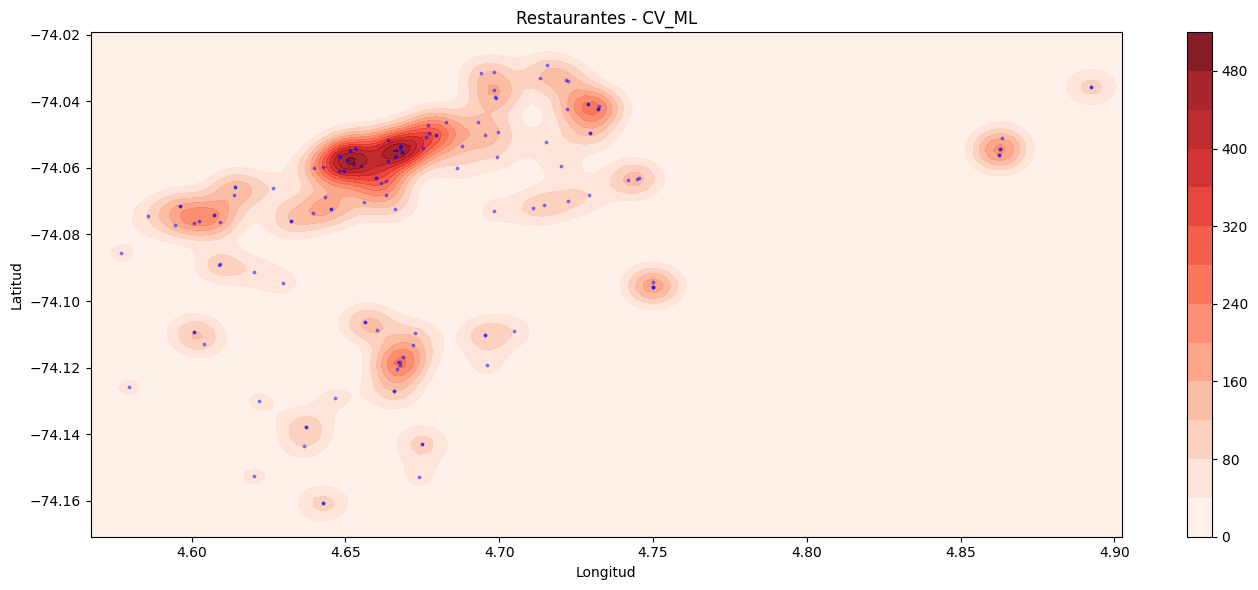

In [23]:
# Construir matriz de características X
df_geo = data.dropna(subset=["Latitud", "Longitud"]).copy()
X = df_geo[["Latitud", "Longitud"]].to_numpy()

# Calcular KDE con selección de ancho de banda por validación cruzada (cv_ml)
kde_cv = sm.nonparametric.KDEMultivariate(
    data=X,
    var_type="cc",
    bw="cv_ml"
)

# Mostrar información sobre anchos de banda
print("Anchos de banda estimados:", kde_cv.bw)
print("")

# Grilla para evaluar la densidad
pad = 0.01
x_min, x_max = X[:,0].min() - pad, X[:,0].max() + pad   # lon
y_min, y_max = X[:,1].min() - pad, X[:,1].max() + pad   # lat
x_grid = np.linspace(x_min, x_max, 120)
y_grid = np.linspace(y_min, y_max, 120)
xx, yy = np.meshgrid(x_grid, y_grid)
grid_points = np.column_stack((xx.ravel(), yy.ravel()))

# Densidad en las ubicaciones observadas
densidad_cv = kde_cv.pdf(data_predict=grid_points).reshape(xx.shape)

# Grafica resultados KDE con validación cruzada
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
c = ax.contourf(xx, yy, densidad_cv, levels=15, cmap='Reds', alpha=0.9)
ax.scatter(X[:,0], X[:,1], s=3, alpha=0.4, color='blue')
ax.set_title('Restaurantes - CV_ML')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.colorbar(c, ax=ax)
plt.tight_layout()
plt.show()

In [27]:
# Densidad en las ubicaciones observadas en dimension adecuada
dens = kde_cv.pdf(data_predict=X)

# Visualización de densidades del modelo KDE
# Definicion del mapa
centro = [X[:,0].mean(), X[:,1].mean()]
mapa_kde = folium.Map(location=centro, tiles="OpenStreetMap", zoom_start=12)

# Escala de color según densidad KDE
vmin, vmax = float(np.percentile(dens, 1)), float(np.percentile(dens, 99))
cmap = linear.viridis.scale(vmin, vmax)
cmap.caption = "Densidad KDE (bw = cv_ml)"
cmap.add_to(mapa_kde)

# Capa de puntos coloreados por densidad KDE
fg_pts = folium.FeatureGroup(name="Restaurantes por densidad KDE")
for (lat, lon), d in zip(X, dens):
    color = cmap(float(np.clip(d, vmin, vmax)))
    folium.CircleMarker([lat, lon],radius=7,color=color,fill=True, fill_color=color, fill_opacity=1.0, weight=0.5, tooltip=f"Densidad KDE: {d:.4f}").add_to(fg_pts)
fg_pts.add_to(mapa_kde)
folium.LayerControl().add_to(mapa_kde)

# Mostrar el mapa
display(mapa_kde)

**Comparativa GMM vs KDE:**

| Criterio | GMM | KDE |
|---|---|---|
| Tipo de modelo | Paramétrico | No paramétrico |
| Salida | Etiquetas de cluster + probabilidades | Superficie continua de densidad |
| Uso recomendado | Segmentar zonas, comparar grupos | Identificar intensidad y hotspots |
| Fortaleza | Fronteras claras, asignación de cada sede | Transiciones suaves, sin asumir número de grupos |

**Conclusión:** GMM y KDE son complementarios y responden preguntas distintas:

1. **¿A qué zona pertenece cada restaurante?** → GMM
2. **¿Dónde está la mayor concentración de oferta?** → KDE

Ambos modelos coinciden en señalar el **corredor oriental de Bogotá (Chapinero–Teusaquillo)** como la zona de mayor concentración del Burger Master 2022, con el grupo de **Chía** claramente separado y focos secundarios en el norte y occidente de la ciudad.

**Aplicación práctica:** este análisis permite a los organizadores del evento segmentar comunicaciones por zona geográfica, priorizar la distribución de material promocional y orientar a los asistentes hacia los clústeres con mayor densidad de opciones según su punto de partida.